In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import datetime

In [4]:
yt_df = pd.read_csv('USvideos.csv', parse_dates=['publish_time'])

In [5]:
yt_df["publish_time"] = yt_df["publish_time"].dt.floor("10min")

In [6]:
yt_df['trending_date'] = pd.to_datetime(yt_df['trending_date'], format="%y.%d.%m").dt.floor("10min")

In [7]:
yt_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:10:00+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:00:00+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:00+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:00:00+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [8]:
yt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40949 non-null  object             
 1   trending_date           40949 non-null  datetime64[ns]     
 2   title                   40949 non-null  object             
 3   channel_title           40949 non-null  object             
 4   category_id             40949 non-null  int64              
 5   publish_time            40949 non-null  datetime64[ns, UTC]
 6   tags                    40949 non-null  object             
 7   views                   40949 non-null  int64              
 8   likes                   40949 non-null  int64              
 9   dislikes                40949 non-null  int64              
 10  comment_count           40949 non-null  int64              
 11  thumbnail_link          40949 non-null  o

In [9]:
yt_df.describe()

,trending_date,category_id,views,likes,dislikes,comment_count
count,40949,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,2018-02-27 06:22:42.494810624,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
min,2017-11-14 00:00:00,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,2018-01-04 00:00:00,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,2018-02-26 00:00:00,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,2018-04-24 00:00:00,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,2018-06-14 00:00:00,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06
std,NaN,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04


In [10]:
yt_df.sample(5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
36546,RxlSl-kG3qg,2018-05-23,We Are So Blessed | Acacia Kersey,acaciacutie,23,2018-05-02 19:00:00+00:00,"acacia|""brinley""|""acaciacutie""|""acaciabrinley""...",389001,27256,591,2662,https://i.ytimg.com/vi/RxlSl-kG3qg/default.jpg,False,False,False,Today's video is one of my most favorite video...
3081,qXivpclxftM,2017-11-29,Weird Workout Videos - JonTron,JonTronShow,23,2017-11-25 19:10:00+00:00,"jontron|""weird workout videos""|""workout""|""mark...",3216259,210529,4366,25719,https://i.ytimg.com/vi/qXivpclxftM/default.jpg,False,False,False,Earn FREE cash and gift cards! $5 bonus for ON...
35269,UE-kaxIiNPQ,2018-05-17,Rihanna on Her Divine Dress and Co-Hosting Wit...,Vogue,26,2018-05-08 01:20:00+00:00,"liza|""liza koshy""|""met gala""|""the met""|""met ga...",2462729,68071,1472,2710,https://i.ytimg.com/vi/UE-kaxIiNPQ/default.jpg,False,False,False,Rihanna talks with Liza Koshy about her beaded...
36844,JfQ3W0wjGh4,2018-05-25,My Dad Hustled Me Hard,itsAlexClark,1,2018-05-16 21:50:00+00:00,"its alex clark|""itsalexclark""|""alex clark""|""it...",1251859,38054,1217,4928,https://i.ytimg.com/vi/JfQ3W0wjGh4/default.jpg,False,False,False,What my dad did is inexcusable.... Not the fat...
25293,LeFxjRMv5U8,2018-03-22,Meet Cora,Kitty Hawk,28,2018-03-13 04:50:00+00:00,"flying car|""kitty hawk""|""drone""|""tesla""|""air t...",733893,5260,408,1086,https://i.ytimg.com/vi/LeFxjRMv5U8/default.jpg,False,False,False,"Meet Cora, Kitty Hawk's prototype air taxi tha..."


Ideas:
Most popular category ID's,
Best time of the year/month to post (Time of year, Views/Likes)

In [11]:
#yt_cat_df = pd.read_json("US_category_id.json")

In [12]:
import json

with open("US_category_id.json") as yt_cat:
    data = json.load(yt_cat)

yt_cat_flat = pd.json_normalize(data, record_path="items")

In [13]:
category_dict = {}
for index, row in yt_cat_flat.iterrows(): 
    cat_id = row['id'] 
    title = row['snippet.title']  
    category_dict[cat_id] = title 
    print(f"ID: {cat_id} | Title: {title}") 
print("\nYour final dictionary:") 
print(category_dict)

ID: 1 | Title: Film & Animation
ID: 2 | Title: Autos & Vehicles
ID: 10 | Title: Music
ID: 15 | Title: Pets & Animals
ID: 17 | Title: Sports
ID: 18 | Title: Short Movies
ID: 19 | Title: Travel & Events
ID: 20 | Title: Gaming
ID: 21 | Title: Videoblogging
ID: 22 | Title: People & Blogs
ID: 23 | Title: Comedy
ID: 24 | Title: Entertainment
ID: 25 | Title: News & Politics
ID: 26 | Title: Howto & Style
ID: 27 | Title: Education
ID: 28 | Title: Science & Technology
ID: 29 | Title: Nonprofits & Activism
ID: 30 | Title: Movies
ID: 31 | Title: Anime/Animation
ID: 32 | Title: Action/Adventure
ID: 33 | Title: Classics
ID: 34 | Title: Comedy
ID: 35 | Title: Documentary
ID: 36 | Title: Drama
ID: 37 | Title: Family
ID: 38 | Title: Foreign
ID: 39 | Title: Horror
ID: 40 | Title: Sci-Fi/Fantasy
ID: 41 | Title: Thriller
ID: 42 | Title: Shorts
ID: 43 | Title: Shows
ID: 44 | Title: Trailers

Your final dictionary:
{'1': 'Film & Animation', '2': 'Autos & Vehicles', '10': 'Music', '15': 'Pets & Animals', '17

In [14]:
category_dict

{'1': 'Film & Animation',
 '2': 'Autos & Vehicles',
 '10': 'Music',
 '15': 'Pets & Animals',
 '17': 'Sports',
 '18': 'Short Movies',
 '19': 'Travel & Events',
 '20': 'Gaming',
 '21': 'Videoblogging',
 '22': 'People & Blogs',
 '23': 'Comedy',
 '24': 'Entertainment',
 '25': 'News & Politics',
 '26': 'Howto & Style',
 '27': 'Education',
 '28': 'Science & Technology',
 '29': 'Nonprofits & Activism',
 '30': 'Movies',
 '31': 'Anime/Animation',
 '32': 'Action/Adventure',
 '33': 'Classics',
 '34': 'Comedy',
 '35': 'Documentary',
 '36': 'Drama',
 '37': 'Family',
 '38': 'Foreign',
 '39': 'Horror',
 '40': 'Sci-Fi/Fantasy',
 '41': 'Thriller',
 '42': 'Shorts',
 '43': 'Shows',
 '44': 'Trailers'}

In [15]:
yt_cat_flat.head()

,kind,etag,id,snippet.channelId,snippet.title,snippet.assignable
0,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKm...",1,UCBR8-60-B28hp2BmDPdntcQ,Film & Animation,True
1,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/UZ1oLIIz2dxIhO45Z...",2,UCBR8-60-B28hp2BmDPdntcQ,Autos & Vehicles,True
2,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/nqRIq97-xe5XRZTxb...",10,UCBR8-60-B28hp2BmDPdntcQ,Music,True
3,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/HwXKamM1Q20q9BN-o...",15,UCBR8-60-B28hp2BmDPdntcQ,Pets & Animals,True
4,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/9GQMSRjrZdHeb1OEM...",17,UCBR8-60-B28hp2BmDPdntcQ,Sports,True


In [16]:
yt_df['category_id'].value_counts()

category_id
24    9964
10    6472
26    4146
23    3457
22    3210
25    2487
28    2401
1     2345
17    2174
27    1656
15     920
20     817
19     402
2      384
29      57
43      57
Name: count, dtype: int64

In [17]:
# def make_cat_name(category_id):
#     for category_id in category_dict:
#         return['title']
    
# print(make_cat_name(1))

In [18]:
category_dict

{'1': 'Film & Animation',
 '2': 'Autos & Vehicles',
 '10': 'Music',
 '15': 'Pets & Animals',
 '17': 'Sports',
 '18': 'Short Movies',
 '19': 'Travel & Events',
 '20': 'Gaming',
 '21': 'Videoblogging',
 '22': 'People & Blogs',
 '23': 'Comedy',
 '24': 'Entertainment',
 '25': 'News & Politics',
 '26': 'Howto & Style',
 '27': 'Education',
 '28': 'Science & Technology',
 '29': 'Nonprofits & Activism',
 '30': 'Movies',
 '31': 'Anime/Animation',
 '32': 'Action/Adventure',
 '33': 'Classics',
 '34': 'Comedy',
 '35': 'Documentary',
 '36': 'Drama',
 '37': 'Family',
 '38': 'Foreign',
 '39': 'Horror',
 '40': 'Sci-Fi/Fantasy',
 '41': 'Thriller',
 '42': 'Shorts',
 '43': 'Shows',
 '44': 'Trailers'}

In [19]:
yt_df["categories"] = yt_df["category_id"].astype(str).map(category_dict)

In [20]:
yt_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,categories
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:10:00+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:00:00+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Comedy
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:00+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:00:00+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment


In [21]:
yt_df['Views in Millions'] = (yt_df['views'] / 1000000)

In [22]:
yt_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,categories,Views in Millions
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:10:00+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs,0.748374
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment,2.418783
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:00:00+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Comedy,3.191434
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:00+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment,0.343168
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:00:00+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment,2.095731


In [23]:
yt_df.corr(numeric_only=True)

,category_id,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,Views in Millions
category_id,1.000000,-0.168231,-0.173921,-0.033547,-0.076307,0.048949,-0.013506,-0.030011,-0.168231
views,-0.168231,1.000000,0.849177,0.472213,0.617621,0.002677,0.015355,-0.002256,1.000000
likes,-0.173921,0.849177,1.000000,0.447186,0.803057,-0.028918,-0.020888,-0.002641,0.849177
dislikes,-0.033547,0.472213,0.447186,1.000000,0.700184,-0.004431,-0.008230,-0.001853,0.472213
comment_count,-0.076307,0.617621,0.803057,0.700184,1.000000,-0.028277,-0.013819,-0.003725,0.617621
comments_disabled,0.048949,0.002677,-0.028918,-0.004431,-0.028277,1.000000,0.319230,-0.002970,0.002677
ratings_disabled,-0.013506,0.015355,-0.020888,-0.008230,-0.013819,0.319230,1.000000,-0.001526,0.015355
video_error_or_removed,-0.030011,-0.002256,-0.002641,-0.001853,-0.003725,-0.002970,-0.001526,1.000000,-0.002256
Views in Millions,-0.168231,1.000000,0.849177,0.472213,0.617621,0.002677,0.015355,-0.002256,1.000000


In [24]:
yt_df.groupby('categories')['Views in Millions'].sum()

categories
Autos & Vehicles           520.690717
Comedy                    5117.426208
Education                 1180.629990
Entertainment            20604.388195
Film & Animation          7284.156721
Gaming                    2141.218625
Howto & Style             4078.545064
Music                    40132.892190
News & Politics           1473.765704
Nonprofits & Activism      168.941392
People & Blogs            4917.191726
Pets & Animals             764.651989
Science & Technology      3487.756816
Shows                       51.501058
Sports                    4404.456673
Travel & Events            343.557084
Name: Views in Millions, dtype: float64

In [25]:
Views_in_millions_of_the_cats = yt_df.groupby('categories')['views'].sum()
Views_in_millions_of_the_cats = Views_in_millions_of_the_cats.reset_index()

In [26]:
# plt.figure(figsize=(20,12))
fig = px.bar(Views_in_millions_of_the_cats, x='categories', y='views', title='Views per Million of Each Category')
fig.show()
# plt.title('Views Per Category on Youtube')
# plt.xlabel('Categories')
# plt.ylabel('Views in Millions')
# plt.tight_layout()
# plt.xticks(rotation=45)
# plt.show()

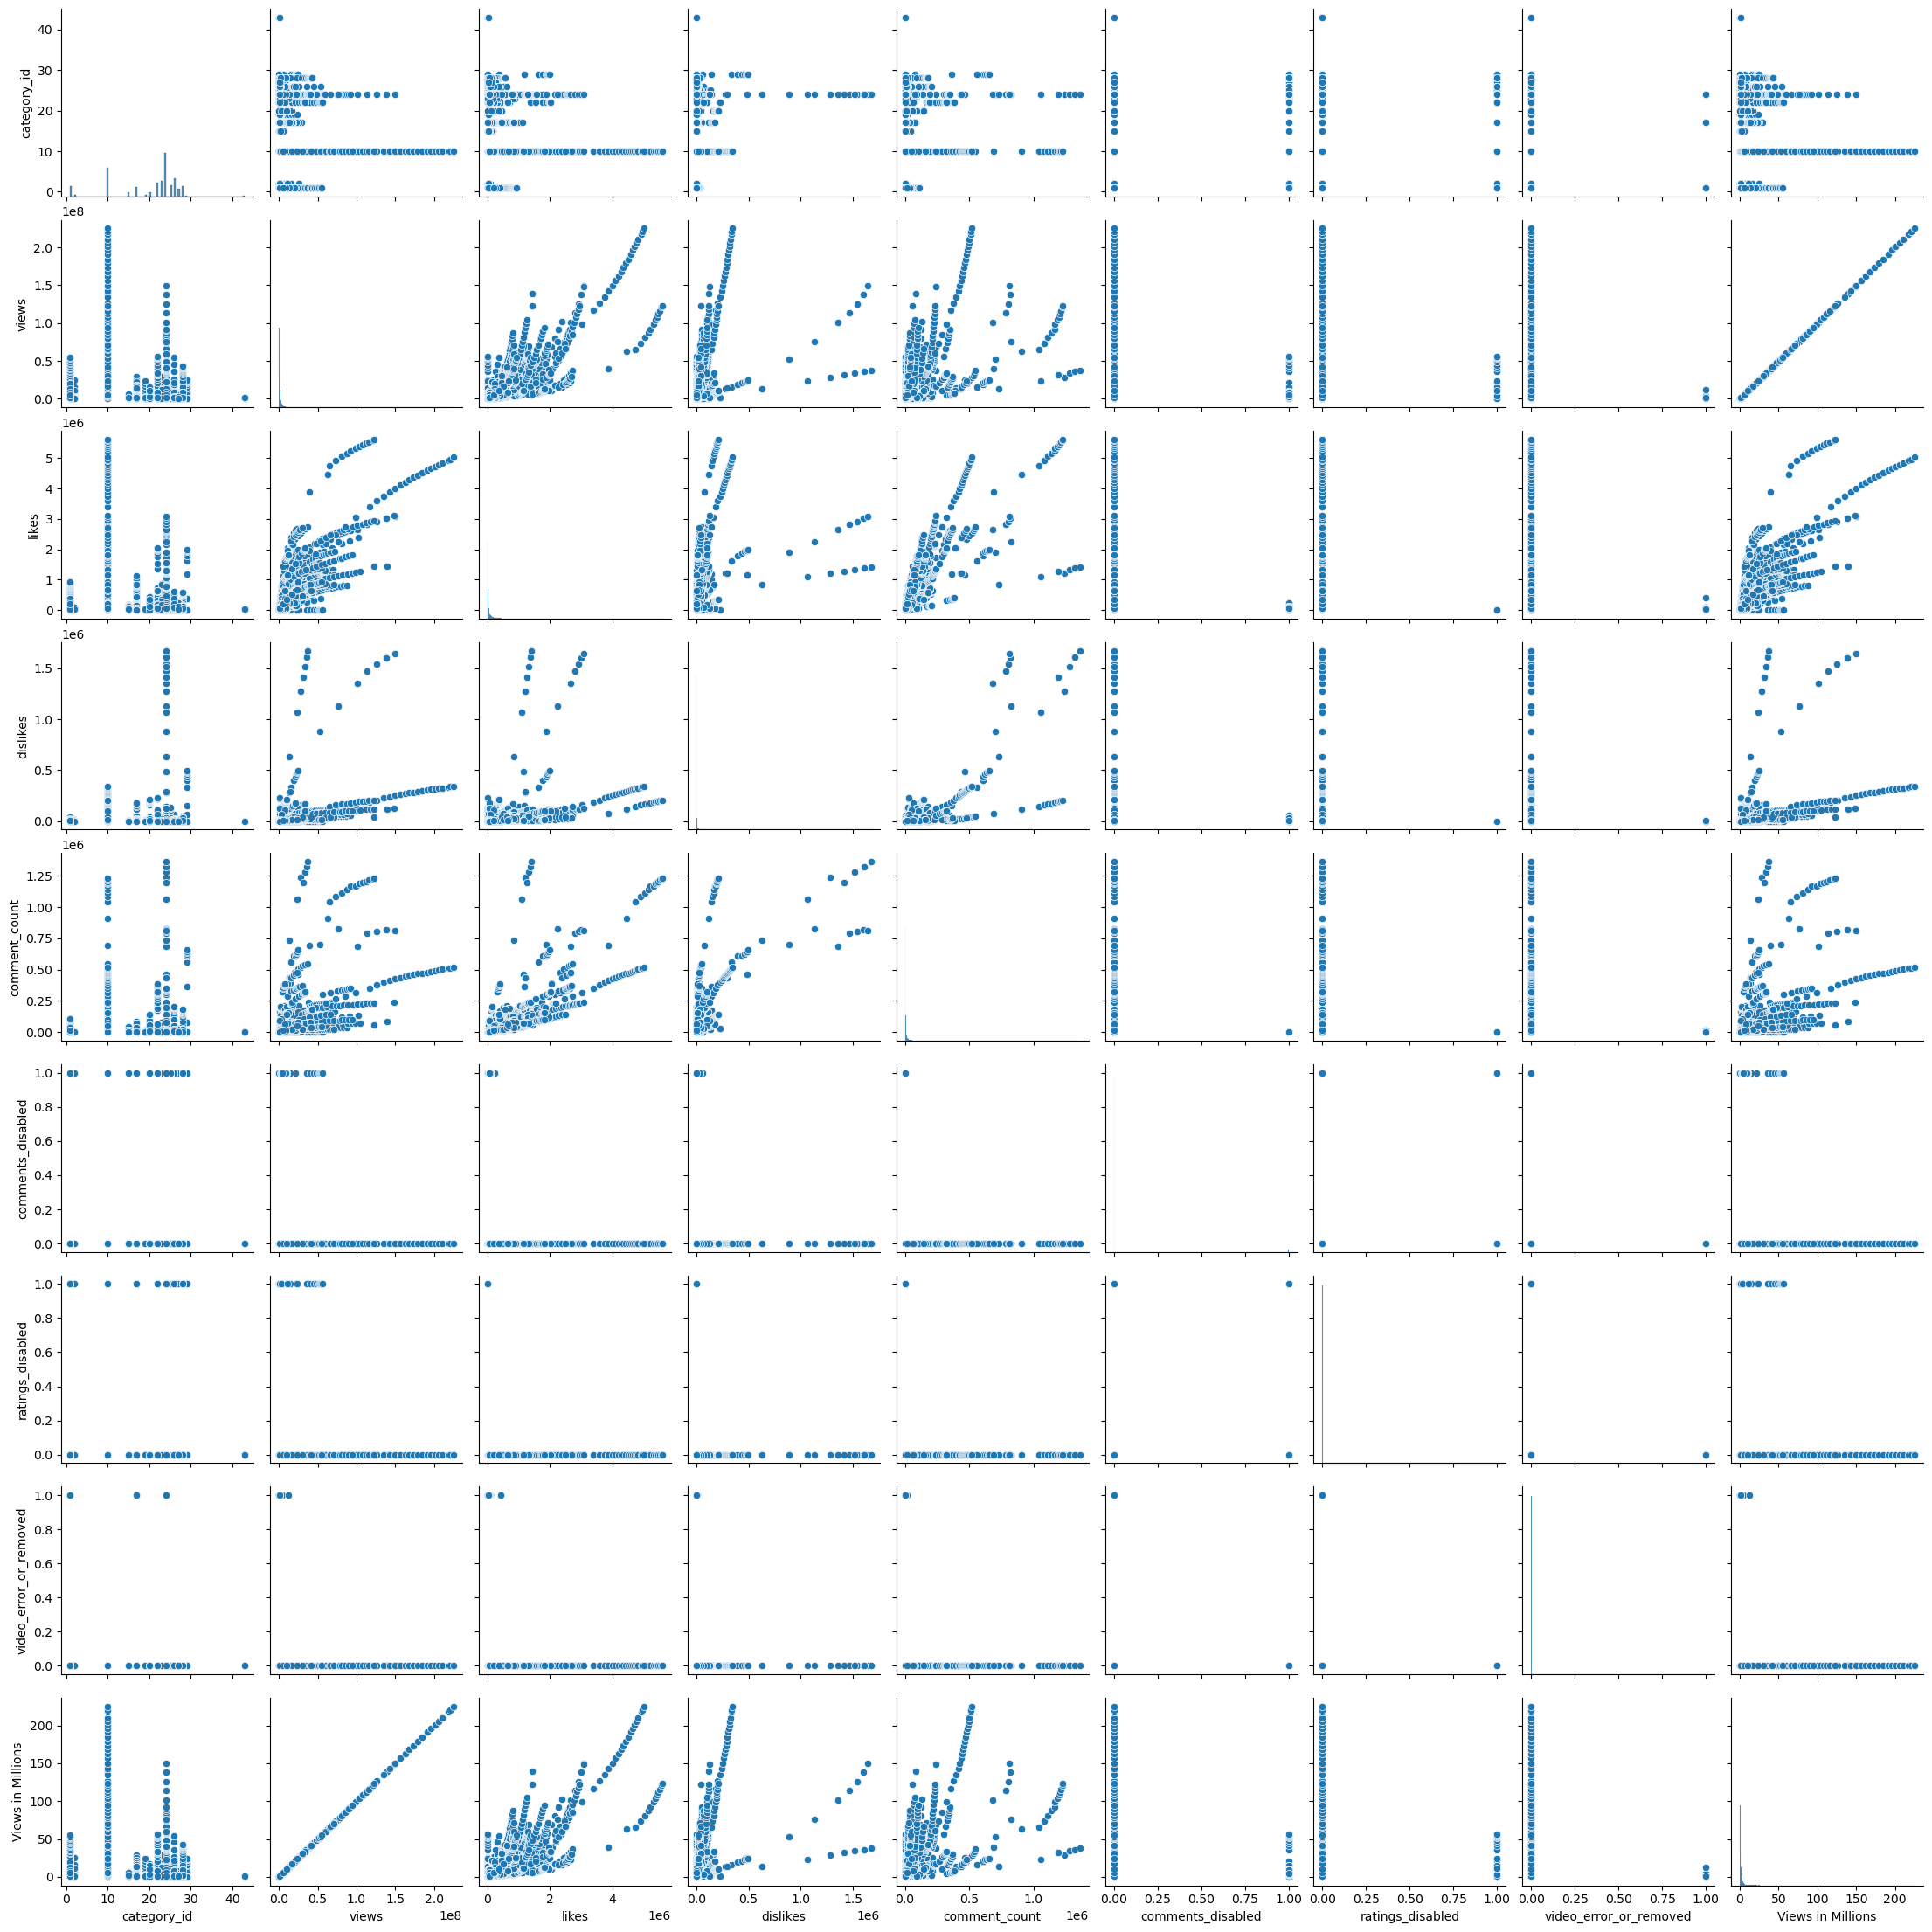

In [27]:
sns.pairplot(yt_df)

In [28]:
yt_df['time uploaded'] = yt_df['publish_time'].dt.time

In [29]:
yt_df.head(

)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,categories,Views in Millions,time uploaded
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:10:00+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs,0.748374,17:10:00
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment,2.418783,07:30:00
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:00:00+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Comedy,3.191434,19:00:00
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:00+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment,0.343168,11:00:00
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:00:00+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment,2.095731,18:00:00


In [30]:
yt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40949 non-null  object             
 1   trending_date           40949 non-null  datetime64[ns]     
 2   title                   40949 non-null  object             
 3   channel_title           40949 non-null  object             
 4   category_id             40949 non-null  int64              
 5   publish_time            40949 non-null  datetime64[ns, UTC]
 6   tags                    40949 non-null  object             
 7   views                   40949 non-null  int64              
 8   likes                   40949 non-null  int64              
 9   dislikes                40949 non-null  int64              
 10  comment_count           40949 non-null  int64              
 11  thumbnail_link          40949 non-null  o

In [31]:
yt_df["time uploaded"] = yt_df["time uploaded"].apply(lambda t: datetime.datetime.combine(datetime.datetime.today(), t))

In [32]:
yt_df = yt_df.sort_values(by="time uploaded")
yt_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,categories,Views in Millions,time uploaded
31937,LX0wFKvticI,2018-04-30,Young girl overjoyed after receiving puck from...,NHL,17,2018-04-16 00:00:00+00:00,"NHL|""National Hockey League""|""Hockey""|""Washing...",421714,4619,116,629,https://i.ytimg.com/vi/LX0wFKvticI/default.jpg,False,False,False,Brett Connolly spots a young girl in the first...,Sports,0.421714,2026-02-19
39146,QDk-xa1oBXw,2018-06-05,GRAPEFRUIT PEEL STEAK Bistec de Toronja | HARD...,emmymadeinjapan,26,2018-05-11 00:00:00+00:00,"bistek|""toronja""|""grapefruit""|""peel""|""pith""|""f...",212335,8715,183,1671,https://i.ytimg.com/vi/QDk-xa1oBXw/default.jpg,False,False,False,Get your WINSTON tee here: http://bit.ly/winst...,Howto & Style,0.212335,2026-02-19
15385,0ufNmUyf2co,2018-01-31,Bike Check - My freak bikes,Seth's Bike Hacks,26,2018-01-25 00:00:00+00:00,"bikes|""bicycles""|""weird bikes""|""custom bikes""|...",238483,7894,81,778,https://i.ytimg.com/vi/0ufNmUyf2co/default.jpg,False,False,False,Some of the questions I get most are about my ...,Howto & Style,0.238483,2026-02-19
10754,nk-_RJcWd4M,2018-01-06,"Clownfish That Look like Cows?! (Also, Address...",Taylor Nicole Dean,15,2017-12-31 00:00:00+00:00,"taylor nicole dean|""taylor dean""|""pets""|""cowfi...",428518,24906,621,5367,https://i.ytimg.com/vi/nk-_RJcWd4M/default.jpg,False,False,False,"Introducing the Black Storm Clownfish, I am lu...",Pets & Animals,0.428518,2026-02-19
12813,IyRRk3wgKMo,2018-01-19,LOOK AT WHAT HE TURNED ME INTO... (ft. James C...,FaZe Rug,20,2018-01-18 00:00:00+00:00,"faze rug|""rug""|""makeup""|""make""|""up""|""make up""|...",1513869,127793,24274,55251,https://i.ytimg.com/vi/IyRRk3wgKMo/default.jpg,False,False,False,THIS WAS SO FUNNY\nCHECK OUT THE VID ON JAMES ...,Gaming,1.513869,2026-02-19


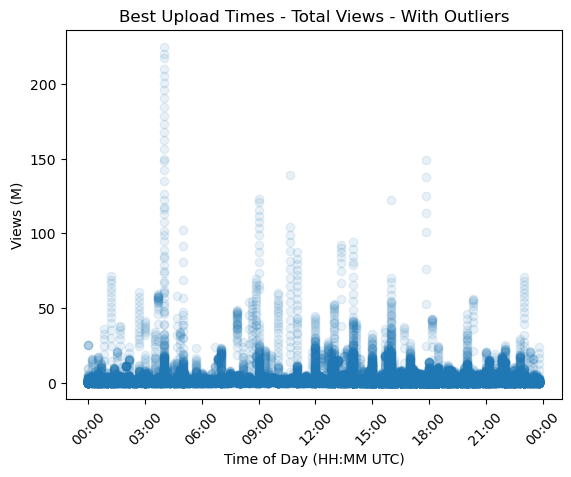

In [33]:
fig, ax = plt.subplots()

ax.scatter(yt_df['time uploaded'], yt_df['Views in Millions'], alpha=0.1)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_title("Best Upload Times - Total Views - With Outliers")
ax.set_xlabel("Time of Day (HH:MM UTC)")
ax.set_ylabel("Views (M)")
# plt.plot(yt_df['time uploaded'], yt_df['views'])
plt.xticks(rotation=45)
plt.show()

In [34]:
mean_views_by_time = yt_df.groupby('time uploaded')["views"].mean()
mean_views_by_time.head()

time uploaded
2026-02-19 00:00:00    9.476801e+05
2026-02-19 00:10:00    1.703100e+06
2026-02-19 00:20:00    1.219014e+06
2026-02-19 00:30:00    1.583763e+06
2026-02-19 00:40:00    1.937709e+06
Name: views, dtype: float64

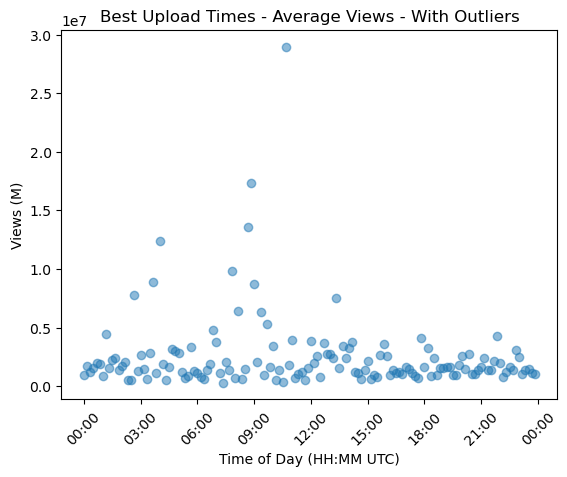

In [35]:
fig, ax = plt.subplots()

ax.scatter(mean_views_by_time.index, mean_views_by_time, alpha=0.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_title("Best Upload Times - Average Views - With Outliers")
ax.set_xlabel("Time of Day (HH:MM UTC)")
ax.set_ylabel("Views (M)")
# plt.plot(yt_df['time uploaded'], yt_df['views'])
plt.xticks(rotation=45)
plt.show()

In [36]:
stand_dev_views = np.std(yt_df["views"])

yt_no_views_outliers = yt_df[yt_df["views"] < (yt_df["views"].mean() + 2 * stand_dev_views)]

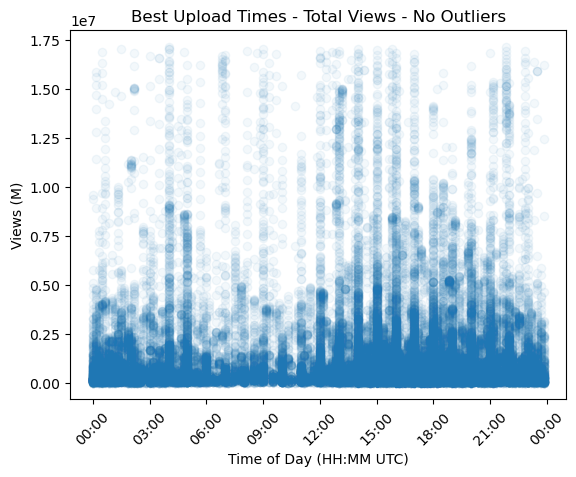

In [37]:
fig, ax = plt.subplots()

ax.scatter(yt_no_views_outliers['time uploaded'], yt_no_views_outliers['views'], alpha=0.05)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_title("Best Upload Times - Total Views - No Outliers")
ax.set_xlabel("Time of Day (HH:MM UTC)")
ax.set_ylabel("Views (M)")
# plt.plot(yt_df['time uploaded'], yt_df['views'])
plt.xticks(rotation=45)
plt.show()

In [38]:
mean_views_by_time = yt_no_views_outliers.groupby('time uploaded')["views"].mean()
mean_views_by_time.head()

time uploaded
2026-02-19 00:00:00    7.025182e+05
2026-02-19 00:10:00    1.703100e+06
2026-02-19 00:20:00    1.219014e+06
2026-02-19 00:30:00    1.524732e+06
2026-02-19 00:40:00    1.937709e+06
Name: views, dtype: float64

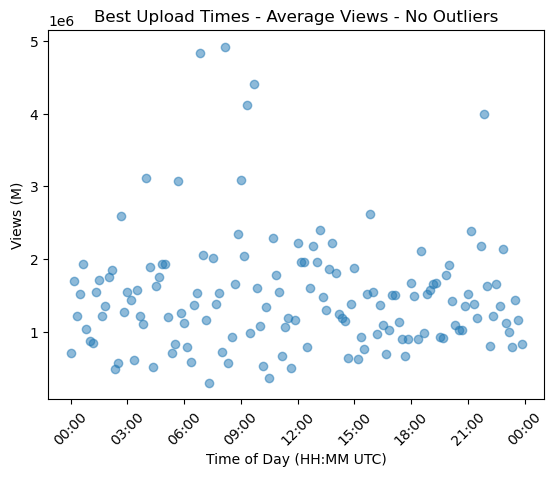

In [39]:
fig, ax = plt.subplots()

ax.scatter(mean_views_by_time.index, mean_views_by_time, alpha=0.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_title("Best Upload Times - Average Views - No Outliers")
ax.set_xlabel("Time of Day (HH:MM UTC)")
ax.set_ylabel("Views (M)")
# plt.plot(yt_df['time uploaded'], yt_df['views'])
plt.xticks(rotation=45)
plt.show()

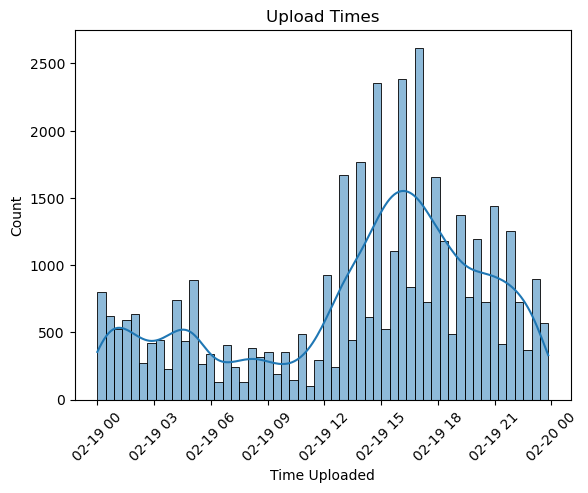

In [40]:
sns.histplot(data=yt_no_views_outliers, x="time uploaded", kde=True)
plt.title("Upload Times")
plt.xlabel("Time Uploaded")
plt.xticks(rotation=45)
plt.show()

In [41]:
yt_df["day_uploaded"] = yt_df["publish_time"].dt.day_name()

In [42]:
yt_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,categories,Views in Millions,time uploaded,day_uploaded
31937,LX0wFKvticI,2018-04-30,Young girl overjoyed after receiving puck from...,NHL,17,2018-04-16 00:00:00+00:00,"NHL|""National Hockey League""|""Hockey""|""Washing...",421714,4619,116,629,https://i.ytimg.com/vi/LX0wFKvticI/default.jpg,False,False,False,Brett Connolly spots a young girl in the first...,Sports,0.421714,2026-02-19,Monday
39146,QDk-xa1oBXw,2018-06-05,GRAPEFRUIT PEEL STEAK Bistec de Toronja | HARD...,emmymadeinjapan,26,2018-05-11 00:00:00+00:00,"bistek|""toronja""|""grapefruit""|""peel""|""pith""|""f...",212335,8715,183,1671,https://i.ytimg.com/vi/QDk-xa1oBXw/default.jpg,False,False,False,Get your WINSTON tee here: http://bit.ly/winst...,Howto & Style,0.212335,2026-02-19,Friday
15385,0ufNmUyf2co,2018-01-31,Bike Check - My freak bikes,Seth's Bike Hacks,26,2018-01-25 00:00:00+00:00,"bikes|""bicycles""|""weird bikes""|""custom bikes""|...",238483,7894,81,778,https://i.ytimg.com/vi/0ufNmUyf2co/default.jpg,False,False,False,Some of the questions I get most are about my ...,Howto & Style,0.238483,2026-02-19,Thursday
10754,nk-_RJcWd4M,2018-01-06,"Clownfish That Look like Cows?! (Also, Address...",Taylor Nicole Dean,15,2017-12-31 00:00:00+00:00,"taylor nicole dean|""taylor dean""|""pets""|""cowfi...",428518,24906,621,5367,https://i.ytimg.com/vi/nk-_RJcWd4M/default.jpg,False,False,False,"Introducing the Black Storm Clownfish, I am lu...",Pets & Animals,0.428518,2026-02-19,Sunday
12813,IyRRk3wgKMo,2018-01-19,LOOK AT WHAT HE TURNED ME INTO... (ft. James C...,FaZe Rug,20,2018-01-18 00:00:00+00:00,"faze rug|""rug""|""makeup""|""make""|""up""|""make up""|...",1513869,127793,24274,55251,https://i.ytimg.com/vi/IyRRk3wgKMo/default.jpg,False,False,False,THIS WAS SO FUNNY\nCHECK OUT THE VID ON JAMES ...,Gaming,1.513869,2026-02-19,Thursday


In [43]:
views_per_day = yt_df.groupby("day_uploaded")["views"].mean()

In [44]:
views_per_day.head()

day_uploaded
Friday      3.373693e+06
Monday      1.991128e+06
Saturday    1.729033e+06
Sunday      2.953206e+06
Thursday    2.315077e+06
Name: views, dtype: float64

In [45]:
days_lst = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']


In [50]:
views_per_day = views_per_day.reset_index()

In [51]:
views_per_day.head()

,day_uploaded,views
0,Friday,3.373693e+06
1,Monday,1.991128e+06
2,Saturday,1.729033e+06
3,Sunday,2.953206e+06
4,Thursday,2.315077e+06


<Axes: xlabel='day_uploaded', ylabel='views'>

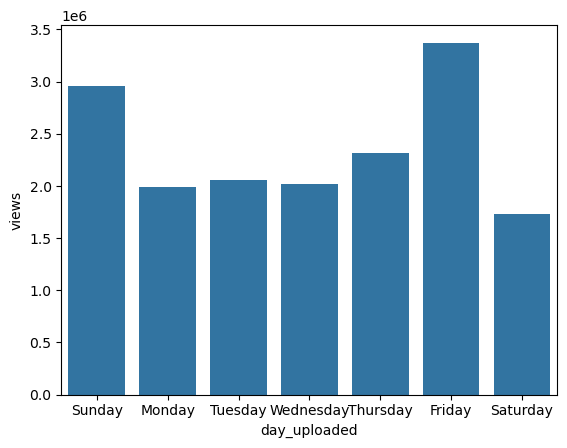

In [54]:
sns.barplot(data=views_per_day, x='day_uploaded', y ='views', order=days_lst)

In [1]:
yt_df.info()

NameError: name 'yt_df' is not defined